<div
     style="padding: 20px;
            color: white;
            font-size: 240%;
            text-align: center;
            border-radius: 5px;
            background-color: #023c66;
            overflow: hidden;
            font-weight: 700;
            border: 5px solid #F28C28;">
    EDA Worksheet 1 — Explore, Audit, and Understand
</div>

**Course:** ISA 591 — Introduction to Data Mining in Business  
**Module:** Exploratory Data Analysis (EDA)  
**Focus:** EDA: variable roles, data types, summaries, plots, cardinality, associations, and automated EDA

## Learning Goals

1. Explain the goals of EDA before modeling.
2. Identify the response variable and variables that should not be predictors.
3. Detect variables stored using inappropriate data types.
4. Summarize numeric and categorical variables.
5. Interpret distributions, skewness, and unusual values.
6. Evaluate categorical cardinality and potential model degrees of freedom.
7. Explore bivariate and multivariate associations.
8. Use automated EDA as a supplement—not a replacement—for analyst judgment.
9. Produce an EDA audit recommending the next preparation steps.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
print("Ready!")

Ready!


---

# 1. What Are We Trying to Accomplish With EDA?

The goal of EDA is to **understand the data and identify decisions that must be made before modeling**.

In this course, EDA includes:

- understanding the business problem and response variable
- checking variable types
- summarizing and plotting variables
- finding missing values
- finding unusual or potentially incorrect values
- checking skewness
- checking categorical levels and cardinality
- identifying irrelevant variables
- exploring associations among variables
- deciding what must be encoded, transformed, imputed, combined, or removed

> **EDA is successful when it changes or confirms what you plan to do next.**

---

# 2. The Veterans Marketing Problem

A national veterans' organization wants to better target donation solicitations. Sending solicitations costs money, so the organization wants to identify individuals most likely to donate.

The historical dataset contains two important outcomes:

- `TARGET_B`: whether the person donated
- `TARGET_D`: donation amount for those who donated

For a model whose goal is to predict **whether someone will donate**, our primary response is `TARGET_B`.

In [3]:
## TARGET_B is binary {0,1} - Classification (supervised)
## TARGET_D is numeric ($amount) - Regression (supervised)

df_raw = pd.read_csv("https://raw.githubusercontent.com/martinwg/ISA591/main/data/pva97nk.csv")
df = df_raw.copy()

print("Shape:", df.shape)
df.head()

Shape: (9686, 28)


,TARGET_B,ID,TARGET_D,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome
0,0,14974,NaN,2,4,1,3,$17.00,$13.50,$9.25,$17.00,21,66,8,17,26,3,8,13,A,0,0,NaN,F,U,$0,0,$0
1,0,6294,NaN,1,8,0,3,$20.00,$20.00,$15.88,NaN,26,92,14,35,79,5,5,24,A,0,23,67.0,F,U,$186800,85,$0
2,1,46110,$4.00,6,41,3,20,$6.00,$5.17,$3.73,$5.00,18,111,12,23,51,5,11,22,S,1,0,NaN,M,U,$87600,36,$38750
3,1,185937,$10.00,3,12,3,8,$10.00,$8.67,$8.50,$8.67,9,93,14,22,44,2,6,16,E,1,0,NaN,M,U,$139200,27,$38942
4,0,29637,NaN,1,1,1,1,$20.00,$20.00,$20.00,$20.00,21,21,10,15,13,4,7,6,F,0,35,53.0,M,U,$168100,37,$71509


## Practice 2A — Think Like an Analyst

Answer before doing more coding:

1. What is the business objective?
2. What is the target if our goal is donor/non-donor prediction?
3. Is that target numeric or categorical in meaning?
4. Is this a regression or classification problem?
5. Should `TARGET_D` be used as a predictor for `TARGET_B`? Why or why not?

**Your response here:**  

1.  Predict Donation or Not, or Predict the Amount Donated
2.  TARGET_B
3.  CATEGORICAL (binary)
4.  Classification
5.  No. This creates data leakage (feeding information about y to the model as a predictor)

---

# 3. First Audit: Shape, Head, Info

Three basic commands should become automatic:

```python
df.shape
df.head()
df.info()
```

They answer different questions:

- **shape** → How large is the dataset?
- **head** → What do actual observations look like?
- **info** → Which variables exist, what are their types, and where are missing values?

## Practice 3A — Complete the audit

In [4]:
## info (are there missing values)
## give me the variables that have missing values

missing = df.isna().sum()
missing = missing[missing > 0]
missing

TARGET_D         4843
GiftAvgCard36    1780
DemAge           2407
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9686 entries, 0 to 9685
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TARGET_B          9686 non-null   int64  
 1   ID                9686 non-null   int64  
 2   TARGET_D          4843 non-null   object 
 3   GiftCnt36         9686 non-null   int64  
 4   GiftCntAll        9686 non-null   int64  
 5   GiftCntCard36     9686 non-null   int64  
 6   GiftCntCardAll    9686 non-null   int64  
 7   GiftAvgLast       9686 non-null   object 
 8   GiftAvg36         9686 non-null   object 
 9   GiftAvgAll        9686 non-null   object 
 10  GiftAvgCard36     7906 non-null   object 
 11  GiftTimeLast      9686 non-null   int64  
 12  GiftTimeFirst     9686 non-null   int64  
 13  PromCnt12         9686 non-null   int64  
 14  PromCnt36         9686 non-null   int64  
 15  PromCntAll        9686 non-null   int64  
 16  PromCntCard12     9686 non-null   int64  


---

# 4. Variable Types: Stored Type vs. Actual Meaning

One of the most important ideas from EDA is:

> **The read dtype is not always the correct statistical meaning of the variable.**

Examples in this dataset:

- dollar amounts contain `$`, so Pandas reads them as `object`
- `DemCluster` is stored as a number, but it represents a **category/cluster**

## Practice 4A — Find the dollar-formatted variables

In [6]:
object_cols = df.select_dtypes(include="object").columns
print(object_cols.tolist())

for col in object_cols:
    print(f"\n{col}:")
    print(df[col].head(5).tolist())

['TARGET_D', 'GiftAvgLast', 'GiftAvg36', 'GiftAvgAll', 'GiftAvgCard36', 'StatusCat96NK', 'DemGender', 'DemHomeOwner', 'DemMedHomeValue', 'DemMedIncome']

TARGET_D:
[nan, nan, '$4.00', '$10.00', nan]

GiftAvgLast:
['$17.00', '$20.00', '$6.00', '$10.00', '$20.00']

GiftAvg36:
['$13.50', '$20.00', '$5.17', '$8.67', '$20.00']

GiftAvgAll:
['$9.25', '$15.88', '$3.73', '$8.50', '$20.00']

GiftAvgCard36:
['$17.00', nan, '$5.00', '$8.67', '$20.00']

StatusCat96NK:
['A', 'A', 'S', 'E', 'F']

DemGender:
['F', 'F', 'M', 'M', 'M']

DemHomeOwner:
['U', 'U', 'U', 'U', 'U']

DemMedHomeValue:
['$0', '$186800', '$87600', '$139200', '$168100']

DemMedIncome:
['$0', '$0', '$38750', '$38942', '$71509']


### Question

Which object variables are really numeric quantities?

**Your response here:**  
-

**How to Correct**

You can use the code below to replace the `$` with an empty value and change the variable type to float.



```
## fix $, change to float or int
df['DemMedIncome']  =  df.DemMedIncome.str.replace('$', '').astype('float')
```



In [7]:
## TODO: Correct the variable the following variables:
# TARGET_D
# GiftAvgLast:
# GiftAvg36:
# GiftAvgAll:
# GiftAvgCard36:
# DemMedHomeValue
# DemMedIncome


## Removing - 
## breaking variable into different 34-B-C001

# df['DemMedIncome']  =  df.DemMedIncome.str.replace('$', '').astype('float')

for col in ["TARGET_D", "GiftAvgLast", "GiftAvg36", "GiftAvgAll", "GiftAvgCard36", "DemMedHomeValue", "DemMedIncome"]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(r"[$,]", "", regex=True),
        errors="coerce"
    )


In [8]:
df.head()

,TARGET_B,ID,TARGET_D,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome
0,0,14974,NaN,2,4,1,3,17.0,13.50,9.25,17.00,21,66,8,17,26,3,8,13,A,0,0,NaN,F,U,0,0,0
1,0,6294,NaN,1,8,0,3,20.0,20.00,15.88,NaN,26,92,14,35,79,5,5,24,A,0,23,67.0,F,U,186800,85,0
2,1,46110,4.0,6,41,3,20,6.0,5.17,3.73,5.00,18,111,12,23,51,5,11,22,S,1,0,NaN,M,U,87600,36,38750
3,1,185937,10.0,3,12,3,8,10.0,8.67,8.50,8.67,9,93,14,22,44,2,6,16,E,1,0,NaN,M,U,139200,27,38942
4,0,29637,NaN,1,1,1,1,20.0,20.00,20.00,20.00,21,21,10,15,13,4,7,6,F,0,35,53.0,M,U,168100,37,71509


In [9]:
object_cols = df.select_dtypes(include="object").columns
print(object_cols.tolist())

for col in object_cols:
    print(f"\n{col}:")
    print(df[col].head(5).tolist())

['StatusCat96NK', 'DemGender', 'DemHomeOwner']

StatusCat96NK:
['A', 'A', 'S', 'E', 'F']

DemGender:
['F', 'F', 'M', 'M', 'M']

DemHomeOwner:
['U', 'U', 'U', 'U', 'U']


## Practice 4B — Research about the `DemCluster` variable type.




In [10]:
## DemCluster
#### We do not want the model to think that DemCluster 40 is twice as much as DemCluster 20
#### We need to make these vars object-types

df.DemCluster.value_counts()

DemCluster
40    432
36    401
24    401
35    384
27    331
12    323
49    323
18    321
13    309
30    262
14    248
39    242
0     240
11    236
45    228
43    227
51    220
16    201
41    197
46    196
28    194
2     191
44    185
8     182
17    178
10    175
20    171
21    165
53    158
3     153
42    140
25    135
34    132
23    131
31    125
22    125
1     121
38    118
15    108
26    100
37     99
48     96
5      95
47     86
7      78
29     73
32     72
9      70
50     70
6      53
33     52
4      51
19     50
52     32
Name: count, dtype: int64

**How to Correct**

You can use the code below to convert a numeric variable to object:



```
df['DemCluster'] = df.DemCluster.astype('O')
```



In [11]:
## TODO: Correct the variable "DemCluster"

df['DemCluster'] = df.DemCluster.astype('O')

In [12]:
object_cols = df.select_dtypes(include="object").columns
print(object_cols.tolist())

for col in object_cols:
    print(f"\n{col}:")
    print(df[col].head(5).tolist())

['StatusCat96NK', 'DemCluster', 'DemGender', 'DemHomeOwner']

StatusCat96NK:
['A', 'A', 'S', 'E', 'F']

DemCluster:
[0, 23, 0, 0, 35]

DemGender:
['F', 'F', 'M', 'M', 'M']

DemHomeOwner:
['U', 'U', 'U', 'U', 'U']


---

# 5. Numeric EDA: Summaries and Distributions

For numeric variables, useful first questions are:

- What is the center?
- How variable is it?
- What are the minimum and maximum?
- Is the distribution skewed?
- Are there unusual observations?
- Are there many zeros?

## Practice 5A — Summary statistics

In [13]:
# TODO: Get summary statistics of numeric variables
#### describe method to get summary stats for ALL numeric vars
df.describe().T


,count,mean,std,min,25%,50%,75%,max
TARGET_B,9686.0,0.500000,0.500026,0.00,0.00,0.50,1.00,1.0
ID,9686.0,97975.474086,56550.171120,12.00,48835.50,99106.00,148538.75,191779.0
TARGET_D,4843.0,15.624344,12.445137,1.00,10.00,13.00,20.00,200.0
GiftCnt36,9686.0,3.205451,2.133421,0.00,2.00,3.00,4.00,16.0
GiftCntAll,9686.0,10.507640,8.993401,1.00,4.00,8.00,15.00,91.0
GiftCntCard36,9686.0,1.856597,1.595419,0.00,1.00,1.00,3.00,9.0
GiftCntCardAll,9686.0,5.582490,4.736894,0.00,2.00,4.00,8.00,41.0
GiftAvgLast,9686.0,16.017739,12.041805,0.00,10.00,15.00,20.00,450.0
GiftAvg36,9686.0,14.876203,10.057007,0.00,9.60,13.50,18.50,260.0
GiftAvgAll,9686.0,12.489325,9.209297,1.50,7.75,10.71,15.00,450.0


## Practice 5B — Skewness

A common rule of thumb:

- skewness near 0 → roughly symmetric
- positive → right-skewed
- negative → left-skewed
- `|skewness| > 1` → worth investigating

In [14]:
# TODO: Identify highly skewed variables
#### .skew() 
#### consider transformation for |skewness| > 5

#### Get the top 10 skewed variables
skewness = df.select_dtypes(include=["number"]).skew().dropna()
top_10_skewed = skewness.abs().sort_values(ascending=False).head(10)
top_10_skewed

## np.log(GiftAvgAll)


GiftAvgAll         14.486489
GiftAvgLast         9.918893
GiftAvgCard36       6.051455
GiftAvg36           5.627792
TARGET_D            5.169490
PromCnt12           2.873723
DemMedHomeValue     2.378211
GiftCntAll          1.863109
GiftCntCardAll      1.331353
GiftCnt36           1.288353
dtype: float64

### Interpretation

Identify two highly skewed variables. Why might skewness matter later for some modeling methods?

**Your response here:**  
-

## Practice 5C — Histograms for all numeric variables


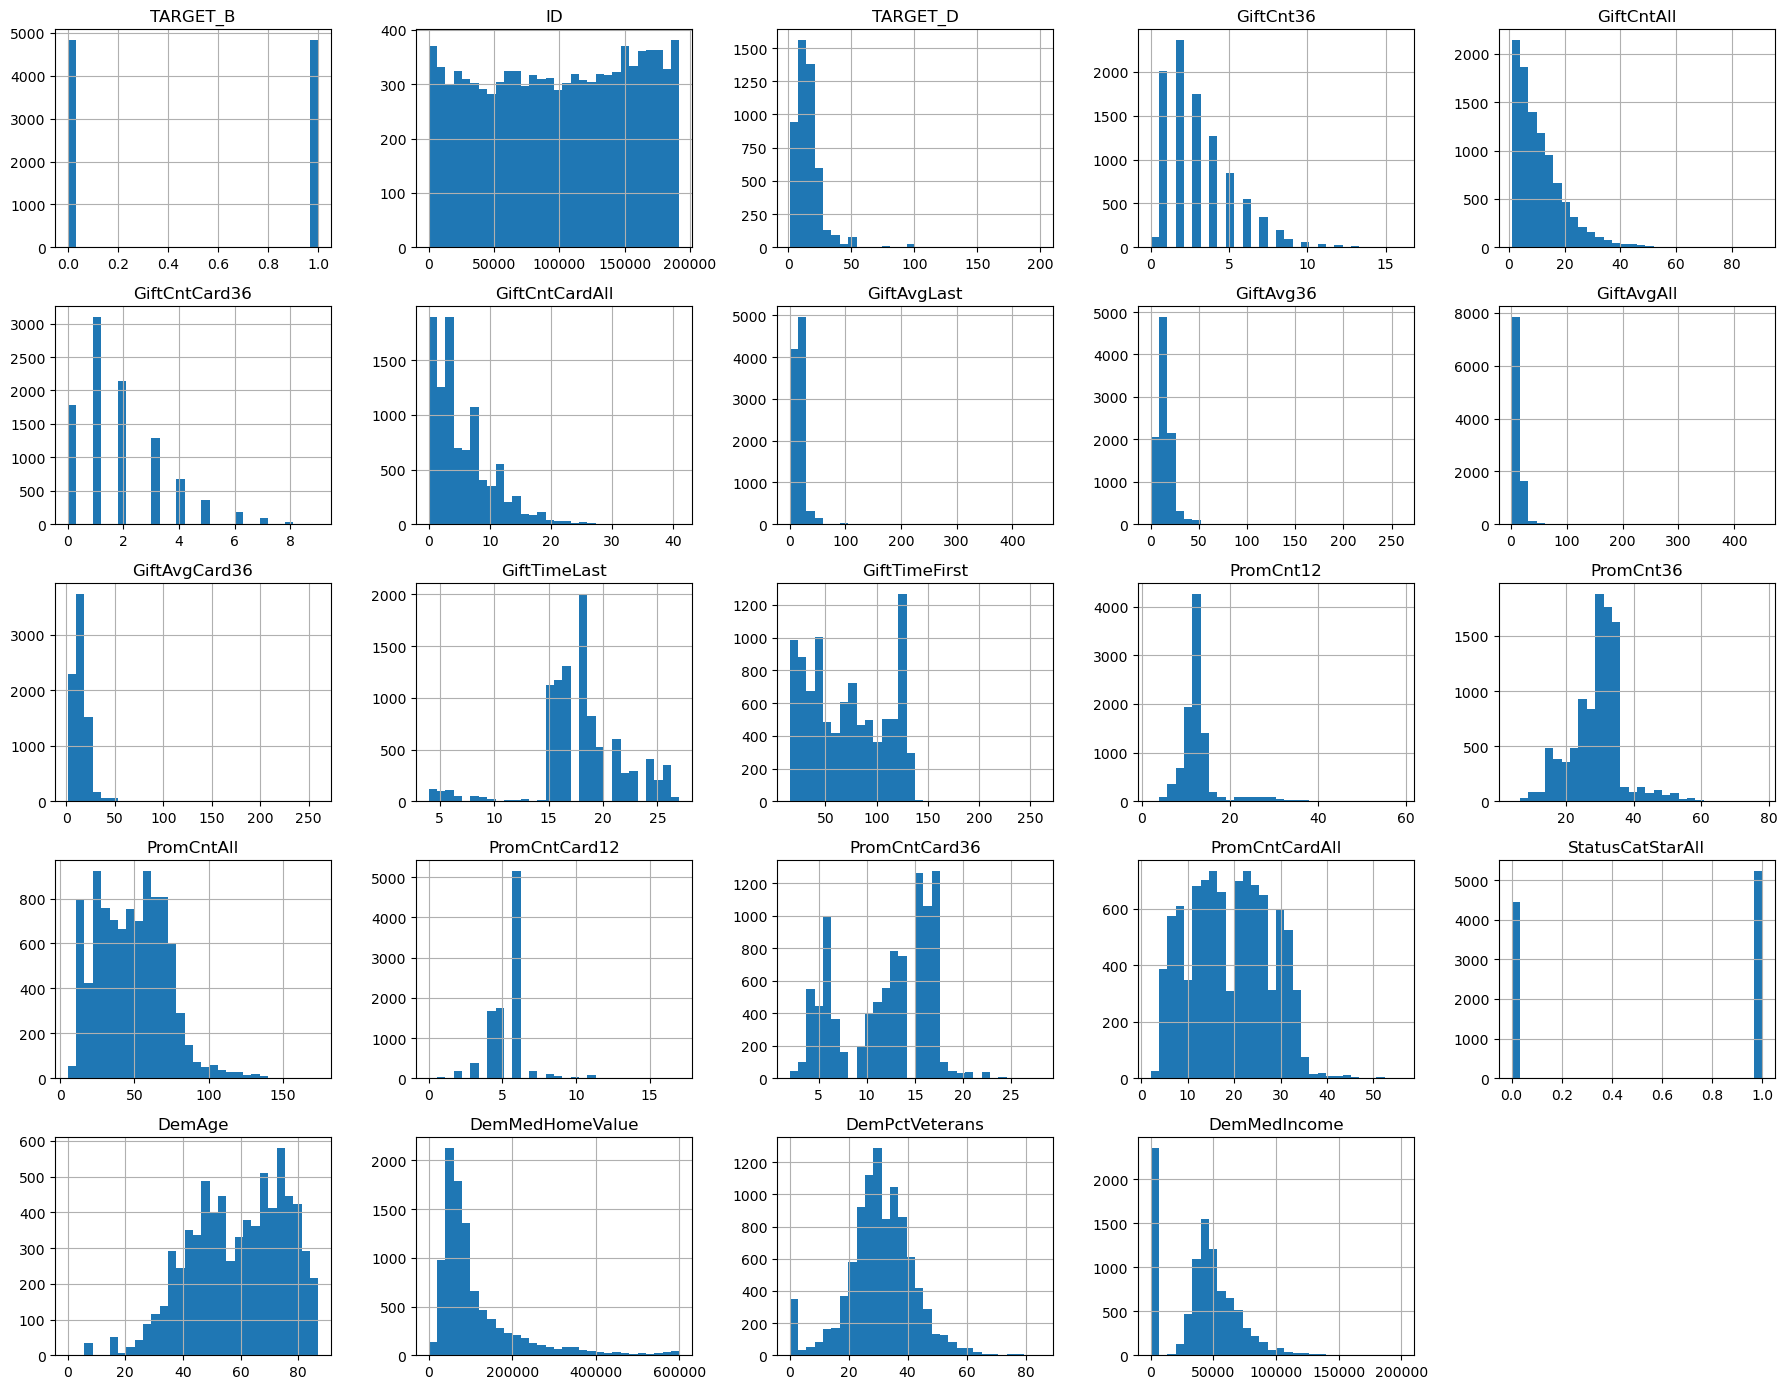

In [15]:
# TODO
df.select_dtypes(include="number").hist(bins=30,figsize=(18, 14))
plt.tight_layout()
plt.show()

## Practice 5D — Focus on `GiftAvgAll`

Create both a histogram and boxplot.

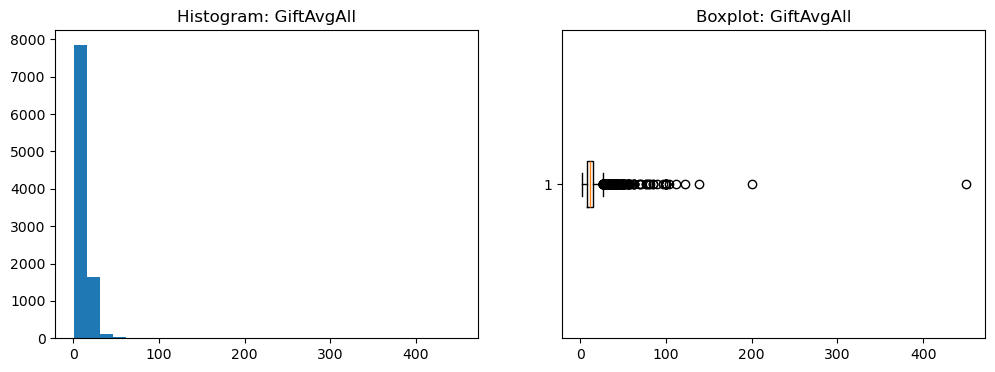

In [16]:
# TODO
### 
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

## shape, anomalies
ax[0].hist(df["GiftAvgAll"].dropna(), bins=30)
ax[0].set_title("Histogram: GiftAvgAll")

## anomalies, outliers
ax[1].boxplot(df["GiftAvgAll"].dropna(), vert=False)
ax[1].set_title("Boxplot: GiftAvgAll")

plt.show()

In [17]:
## identify observations with potentially high outlying values in GiftAvgAll
Q1 = df["GiftAvgAll"].quantile(0.25) ## 25th percentile
Q3 = df["GiftAvgAll"].quantile(0.75) ## 75th percentile
IQR = Q3 - Q1                        ## IQR  
lower_bound = Q1 - 1.5 * IQR             
upper_bound = Q3 + 1.5 * IQR
## create a new data with only the pontential
outliers = df[
    (df["GiftAvgAll"] < lower_bound) |
    (df["GiftAvgAll"] > upper_bound)
]
outliers

,TARGET_B,ID,TARGET_D,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome
8,1,19094,40.0,1,3,0,1,35.0,35.0,28.33,NaN,17,44,15,32,56,6,6,22,A,0,35,NaN,F,U,137300,32,0
18,0,176929,NaN,4,5,1,1,10.0,41.5,35.20,50.0,18,33,14,33,33,6,15,13,A,0,45,NaN,F,U,70000,37,0
20,1,6789,10.0,1,20,1,8,25.0,36.0,26.95,36.0,18,105,21,39,101,6,17,30,A,1,53,80.0,M,U,51500,37,44947
32,0,175262,NaN,2,2,1,1,45.0,32.5,32.50,20.0,18,19,15,21,17,6,9,7,N,0,25,NaN,F,U,103100,24,0
222,0,18753,NaN,1,3,0,1,50.0,35.0,35.00,NaN,18,57,13,30,42,6,6,17,A,0,27,38.0,M,H,68000,30,57099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9604,0,183460,NaN,1,1,1,1,30.0,30.0,30.00,30.0,21,21,11,18,17,5,8,7,F,0,46,61.0,M,H,72800,40,46625
9612,0,183698,NaN,2,2,2,2,50.0,50.0,50.00,50.0,20,23,13,24,23,6,11,9,N,0,44,45.0,M,H,77600,47,47244
9627,1,183940,20.0,3,12,1,5,39.0,36.0,26.67,33.0,18,69,13,34,57,6,17,24,S,1,46,59.0,M,H,40900,39,41008
9633,1,184011,25.0,2,6,1,3,50.0,50.0,37.50,50.0,17,104,13,32,62,6,16,26,A,0,23,82.0,F,H,118300,42,30202


In [18]:
## sort based on the GiftAvgAll
outliers.sort_values(by = "GiftAvgAll", ascending = False)

,TARGET_B,ID,TARGET_D,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome
7389,1,12370,20.0,0,1,0,0,450.0,0.00,450.00,NaN,23,23,25,25,38,6,6,8,N,0,24,NaN,F,H,206700,24,65740
2054,1,14064,100.0,1,1,0,0,200.0,200.00,200.00,NaN,20,20,28,34,35,5,5,6,F,0,24,42.0,M,H,91900,26,65592
1378,0,185153,NaN,2,4,2,2,25.0,260.00,138.75,260.0,5,29,39,53,52,6,13,11,A,0,0,NaN,F,U,80200,0,0
7453,1,12312,95.0,3,6,2,2,219.0,79.67,122.17,76.5,6,29,30,44,48,6,13,11,A,0,31,NaN,F,H,139800,22,43964
4463,0,4194,NaN,2,9,1,7,150.0,150.00,111.11,150.0,18,130,20,42,93,7,18,37,A,0,40,73.0,F,H,56900,31,58514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8711,0,169531,NaN,2,2,1,1,27.0,26.00,26.00,25.0,15,27,12,25,22,5,11,10,N,0,40,66.0,F,U,125600,39,43901
3478,0,78964,NaN,1,2,0,0,27.0,27.00,26.00,NaN,17,30,13,27,24,6,6,10,A,0,20,65.0,F,H,53700,37,59766
8672,0,168799,NaN,3,3,1,1,28.0,26.00,26.00,23.0,26,33,11,30,29,5,14,12,A,0,40,NaN,M,U,106800,44,0
1946,0,50751,NaN,3,10,2,5,60.0,45.00,25.90,55.0,25,89,12,32,64,6,16,25,S,1,13,57.0,F,H,163600,33,100406


In [ ]:
## research the data 
#### consider deleting observation too far away (abnormal)
#### if you get too many anomalies on an important variable, consider creating a different model for them

In [ ]:
## To check for anomalies on high-dimensional multivariate data
#### IsolationForest is good modeling technique

from sklearn.ensemble import IsolationForest

## instance
iso = IsolationForest()

## .fit_predict() -- returns: -1(outliers) and +1(normal)
## needs clean data
## anomaly_prediction = iso.fit_predict(data) ## where data is your dataset

### Interpretation

1. What is the shape of the distribution?
2. Are there observations worth investigating?
3. Does a boxplot "outlier" automatically mean the row should be deleted?

**Your response here:**  
1.  
2.  
3.

---

# 6. Categorical EDA and Cardinality

For categorical variables, useful questions include:

- What are the levels?
- How common is each level?
- Are there missing levels?
- Are some levels extremely rare?
- How many model columns would encoding create?

The number of levels is called **cardinality**.

In [19]:
## .value_counts() helpful to show a table of observations per level
df.DemHomeOwner.value_counts()

DemHomeOwner
H    5377
U    4309
Name: count, dtype: int64

In [20]:
## .nunique() returns the cardinality of variables (very useful for categorical)
df.DemHomeOwner.nunique()

2

## Practice 6A — Frequency tables

In [21]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- StatusCat96NK ---
StatusCat96NK
A    5826
S    2365
F     660
N     574
E     227
L      34
Name: count, dtype: int64

--- DemCluster ---
DemCluster
40    432
36    401
24    401
35    384
27    331
12    323
49    323
18    321
13    309
30    262
14    248
39    242
0     240
11    236
45    228
Name: count, dtype: int64

--- DemGender ---
DemGender
F    5223
M    3925
U     538
Name: count, dtype: int64

--- DemHomeOwner ---
DemHomeOwner
H    5377
U    4309
Name: count, dtype: int64


## Practice 6B — Cardinality

In [ ]:
# TODO: Determine the cardinality of all categorical variables

### Focus on DemCluster
df.DemCluster.nunique()

## 54 levels means 53 dummy-encoded predictors
#### FIX OPTIONS
#### 1) keep top levels (DemCluster 40, 36, ...  then assign the rest to "Other")
#### 2) use a model to determine the clusters MOST/LEAST likely to donate: keep those, assign the rest to "Other"

54

### Model degrees of freedom idea

With ordinary dummy encoding and one reference category:

- 2 levels → 1 dummy column
- 6 levels → 5 dummy columns
- 54 levels → 53 dummy columns

`DemCluster` has many levels, so encoding it naively can substantially increase dimensionality.

### Decision

Would you automatically dummy encode a 54-level variable? What alternatives could you consider?

**Your response here:**  
-

---

# 7. Variables That May Be Inappropriate for Modeling

Before encoding everything, ask:

- Is this an ID?
- Is it constant or nearly constant?
- Is it a second response variable?
- Would it exist when the prediction is made?
- Is it so high-cardinality that it acts like an identifier?

In [23]:
## Categorical vars with too many levels are useless for modeling
#### uninformative: ID, names, 
#### 

unique_counts = df.nunique(dropna=False).sort_values(ascending=False)
unique_counts.head(15)

ID                 9686
DemMedIncome       4463
DemMedHomeValue    2533
GiftAvgAll         1584
GiftAvg36           654
GiftAvgCard36       400
PromCntAll          140
GiftTimeFirst       136
GiftAvgLast          90
DemAge               80
DemPctVeterans       79
TARGET_D             71
GiftCntAll           69
PromCnt36            68
DemCluster           54
dtype: int64

## Practice 7A — Audit `ID` and `TARGET_D`

If our goal is predicting `TARGET_B`:

1. Why is `ID` usually inappropriate as a predictor?
2. Why is `TARGET_D` problematic as a predictor?

**Your response here:**  
1.  
2.

In [24]:
## Drop ID and TARGET_D

df.drop(columns = ['ID', 'TARGET_D'], inplace = True)
df.head()

,TARGET_B,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome
0,0,2,4,1,3,17.0,13.50,9.25,17.00,21,66,8,17,26,3,8,13,A,0,0,NaN,F,U,0,0,0
1,0,1,8,0,3,20.0,20.00,15.88,NaN,26,92,14,35,79,5,5,24,A,0,23,67.0,F,U,186800,85,0
2,1,6,41,3,20,6.0,5.17,3.73,5.00,18,111,12,23,51,5,11,22,S,1,0,NaN,M,U,87600,36,38750
3,1,3,12,3,8,10.0,8.67,8.50,8.67,9,93,14,22,44,2,6,16,E,1,0,NaN,M,U,139200,27,38942
4,0,1,1,1,1,20.0,20.00,20.00,20.00,21,21,10,15,13,4,7,6,F,0,35,53.0,M,U,168100,37,71509


---

# 8. Bivariate and Multivariate EDA

EDA should also investigate relationships.

### Numeric vs. numeric
- scatter plot
- correlation

### Numeric vs. categorical / target
- grouped means/medians
- boxplots

### Categorical vs. categorical
- cross-tabulation
- proportions

## Practice 8A — Scatter plot

In [26]:
# TODO: GiftCntAll vs GiftAvgAll (scatter plot)

### PLOTLY
## !pip install plotly

import plotly.express as px

fig = px.scatter(df, x ="GiftCntAll", y = "GiftAvgAll")
fig.show()

In [27]:
fig = px.scatter_matrix(df, dimensions=["GiftCntAll", "GiftAvgAll", "PromCntAll"])
fig.show()

## Practice 8B — Numeric predictor vs. target

In [30]:
# TODO
#### x = numeric, y = {0,1}
#### relationship

## groupby method
donor_summary = df.groupby("TARGET_B")["GiftAvgAll"].agg(["mean", "median", "std"])
# Hint: group by TARGET_B and summarize GiftAvgAll

donor_summary

,mean,median,std
TARGET_B,,,
0,13.141708,11.5,8.112220
1,11.836942,10.0,10.147922


<Axes: xlabel='TARGET_B', ylabel='GiftAvgAll'>

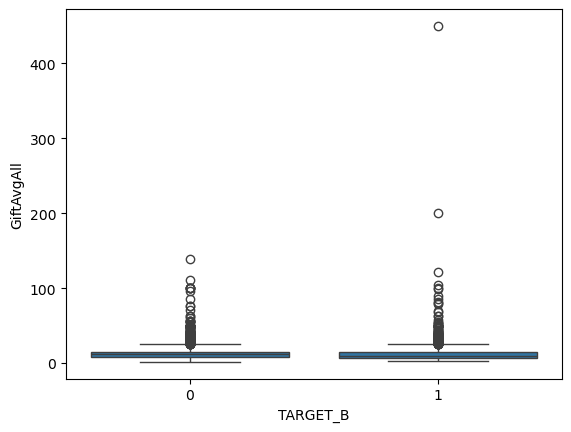

In [31]:
## side by side box plot with x = "GiftAvgAll" and y ="TARGET_B"

import seaborn as sns 

sns.boxplot(x = 'TARGET_B', y = "GiftAvgAll", data = df)

In [ ]:
## FINDING: Customer who donated less (on average) are more likely to continue donating

## Practice 8C — Categorical predictor vs. target

Create a cross-tabulation of `DemHomeOwner` and `TARGET_B`, then convert rows to proportions.

In [33]:
# TODO
## table function (crosstab) can help with predictor (categorical) vs response (categorical)
homeowner_table = pd.crosstab(df['DemHomeOwner'], df['TARGET_B'], normalize = "index")
homeowner_prop = homeowner_table.apply(lambda x: x / x.sum(), axis = 1)

print(homeowner_table)
print("\nRow proportions:")
print(homeowner_prop)

TARGET_B             0         1
DemHomeOwner                    
H             0.496373  0.503627
U             0.504525  0.495475

Row proportions:
TARGET_B             0         1
DemHomeOwner                    
H             0.496373  0.503627
U             0.504525  0.495475


---

# 9. Correlation and Collinearity

Highly related numeric predictors may provide overlapping information.

Correlation does **not** tell the entire story, but it is a useful EDA diagnostic.

In [34]:
numeric_df = df.select_dtypes(include="number").drop(columns=["ID"], errors="ignore")
corr = numeric_df.corr()

# Show strongest absolute correlations, excluding self-correlations
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_pairs = corr.abs().where(mask).stack().sort_values(ascending=False)

corr_pairs.head(15)

GiftAvg36       GiftAvgCard36     0.963606
PromCntAll      PromCntCardAll    0.946153
GiftCntAll      GiftCntCardAll    0.914569
GiftTimeFirst   PromCntCardAll    0.906401
GiftAvgAll      GiftAvgCard36     0.873758
GiftTimeFirst   PromCntAll        0.859004
GiftCnt36       GiftCntCard36     0.844760
GiftAvgLast     GiftAvgAll        0.812801
GiftCntAll      PromCntAll        0.792409
GiftAvgLast     GiftAvgCard36     0.781355
GiftCntCardAll  PromCntCardAll    0.778877
GiftCntAll      PromCntCardAll    0.770467
PromCnt12       PromCnt36         0.769996
GiftAvgLast     GiftAvg36         0.763241
GiftCntCardAll  GiftTimeFirst     0.747874
dtype: float64

## Practice 9A — Small correlation heatmap

Use a manageable subset rather than all variables.

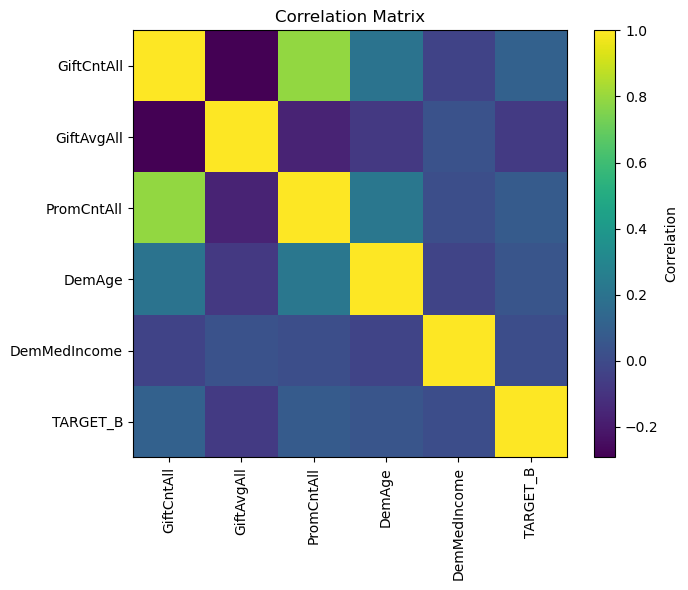

In [35]:
corr_vars = ["GiftCntAll", "GiftAvgAll", "PromCntAll", "DemAge", "DemMedIncome", "TARGET_B"]
small_corr = df[corr_vars].corr()

# TODO
plt.figure(figsize=(7,6))
plt.imshow(small_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_vars)), corr_vars, rotation=90)
plt.yticks(range(len(corr_vars)), corr_vars)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

---

# 10. Missingness Preview

We will make imputation decisions in Worksheet 2.

For now, EDA should answer:

- Which variables are missing?
- How much is missing?
- Is missingness concentrated in certain variables?

In [ ]:
## missing fraction > 50% could signal the need to drop variable
## e.g., 60% do not have a listed Age

In [36]:
# TODO
#### looks for variables with missing values and returns the fraction
missing_fraction = df.isna().mean().sort_values(ascending=False)

missing_fraction = missing_fraction[missing_fraction > 0].sort_values(ascending=False)
missing_fraction

DemAge           0.248503
GiftAvgCard36    0.183770
dtype: float64

In [37]:
## OK TO IMPUTE THESE TWO VARIABLES

### Question

Why is the **fraction missing** generally more interpretable than only the raw number missing?

**Your response here:**  
-

---

# 11. Automated EDA — Useful, But Not a Substitute for Thinking

Last semester you used tools such as:

- `ydata_profiling`
- `Sweetviz`
- `summarytools`

These are excellent **screening tools** for large datasets.

They can quickly flag:

- wrong types
- missingness
- skewness
- high-cardinality variables
- unusual values
- associations

But the software cannot decide whether a strange value is legitimate or whether a variable makes business sense.

### Optional: ydata-profiling

Run only if the package is available.

```python
# !pip install ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Veterans EDA Report", minimal=True)
profile.to_notebook_iframe()
```

### Optional alternatives

```python
# Sweetviz
# !pip install sweetviz
# import sweetviz as sv
# report = sv.analyze(df)
# report.show_html()

# summarytools
# !pip install summarytools
# from summarytools import dfSummary
# dfSummary(df)
```

In [38]:
import sweetviz as sv
report = sv.analyze(df)
report.show_html()

c:\Users\martinwg\.conda\envs\intro-data-mining\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


---

# 13. EDA Audit Challenge

Without fitting a model, complete the analyst report.

1. Primary target:
2. One variable stored with the wrong type:
3. One numeric-looking categorical variable:
4. One highly skewed variable:
5. One high-cardinality variable:
6. One variable with meaningful missingness:
7. One potential unusual-value issue:
8. One variable that should likely be removed before modeling:
9. One possible leakage issue:
10. One strong association or relationship worth investigating:
11. Three preparation actions you recommend for Worksheet 2:

**Your EDA report:**  

1.  
2.  
3.  
4.  
5.  
6.  
7.  
8.  
9.  
10.  
11.

## **NEED TO FIX**

* Need to fix the cardinality of DemCluster (54 levels)
* Transform some highly skewed variables (e.g, GiftAvgAll, ...) - log should work
* Anomalies (1 single donation, with a high value)


In [40]:
## save the data
df.to_csv('data/veterans_eda.csv', index = False)